In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np 
import seaborn as sns 
import folium
from datetime import datetime, timedelta

import pandas as pd
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go

In [58]:
# load excel dataset
raw_data = pd.read_excel(
    '/Users/tish/Documents/Flexible Masters/02806 - Social data and visualization/CODE_Social_data_Visialization/TishDuc.github.io/Displacements_Final_Project/Data/UNHCR_Flow_Data.xlsx',
    sheet_name='DATA'
)

# display the first 10 rows of the dataset
raw_data[:10]

,origin,OriginISO,OriginName,asylum,AsylumISO,AsylumName,AsylumRegion,Population types,Year,Count
0,ALG,DZA,Algeria,MTA,MLT,Malta,Europe,REF,1962,5
1,ANG,AGO,Angola,COD,COD,Dem. Rep. of the Congo,West and Central Africa,REF,1962,20000
2,ANG,AGO,Angola,NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,277
3,BDI,BDI,Burundi,NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,13
4,CHI,CHN,China,NEP,NPL,Nepal,Asia and the Pacific,REF,1962,5
5,COB,COG,"Congo, Republic of",NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,8
6,COD,COD,Dem. Rep. of the Congo,NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,13
7,IRQ,IRQ,Iraq,MTA,MLT,Malta,Europe,REF,1962,17
8,SOM,SOM,Somalia,NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,5
9,SUD,SDN,Sudan,MTA,MLT,Malta,Europe,REF,1962,10


In [59]:
print(raw_data.shape)

(107341, 10)


In [60]:
# -------------------------------------------------------------------
#                      changes to the raw data 
# -------------------------------------------------------------------

#    lower casing
# ------------------
# header to lowercase
raw_data.columns = raw_data.columns.str.lower()
# data to lowercase
for col in raw_data.select_dtypes(include='object'):
    raw_data[col] = raw_data[col].str.lower()

# check for duplicates
# ---------------------
print("number of duplicates found:", raw_data.duplicated().sum()) # ----> 0 duplicates

# check for missing values
# ---------------------
print(raw_data.isnull().sum()) 
# show rows with missing values
# print(raw_data[raw_data.isnull().any(axis=1)])
# remove rows with missing values
raw_data = raw_data.dropna()


# Sanity check it worked:
# ---------------------
# print(raw_data.isnull().sum())
raw_data[:5]



number of duplicates found: 0
origin               0
originiso            0
originname          35
asylum               0
asylumiso            0
asylumname           0
asylumregion        37
population types     0
year                 0
count                0
dtype: int64


,origin,originiso,originname,asylum,asylumiso,asylumname,asylumregion,population types,year,count
0,alg,dza,algeria,mta,mlt,malta,europe,ref,1962,5
1,ang,ago,angola,cod,cod,dem. rep. of the congo,west and central africa,ref,1962,20000
2,ang,ago,angola,nam,nam,namibia,eastern and southern africa,ref,1962,277
3,bdi,bdi,burundi,nam,nam,namibia,eastern and southern africa,ref,1962,13
4,chi,chn,china,nep,npl,nepal,asia and the pacific,ref,1962,5


In [61]:
# deal with annoying country names????

"""
"Côte d'Ivoire", "Iran (Islamic Rep. of)", "Netherlands (Kingdom of the)", "State of Palestine", 
"Lao People's Dem. Rep" = "Laos", 'bolivia (plurinational state of)'

"Dem. Rep. of the Congo" VS "Congo, Republic of"

"""

'\n"Côte d\'Ivoire", "Iran (Islamic Rep. of)", "Netherlands (Kingdom of the)", "State of Palestine", \n"Lao People\'s Dem. Rep" = "Laos", \'bolivia (plurinational state of)\'\n\n"Dem. Rep. of the Congo" VS "Congo, Republic of"\n\n'

In [62]:
# --------------------------------------------------------------
#                      Export cleaned Data
# --------------------------------------------------------------

clean_data = raw_data.copy()

# export cleaned data to csv
clean_data.to_csv('/Users/tish/Documents/Flexible Masters/02806 - Social data and visualization/CODE_Social_data_Visialization/TishDuc.github.io/Displacements_Final_Project/Data/cleaned_data.csv', index=False)

### Project part

In [63]:
# ---------------------------------------------------------------
#                  A closer look at the countries
# ---------------------------------------------------------------


#########################
# QUESTION: 
# should we remove 'unknown/other'?? is that missing data or an appearing country?
#########################

#---------------------------------
#    unique ORIGIN countries
#---------------------------------
# total names and year
unique_origin_countries = clean_data['originname'].unique()
print("Total unique origin countries:", len(unique_origin_countries))

# year of the first and last mention of each country in the origin column
first_mention_origin_country = clean_data.groupby('originname')['year'].min()
last_mention_origin_country = clean_data.groupby('originname')['year'].max()

#---------------------------------
#   unique DESTINATION countries
#---------------------------------
# total name and year
unique_destination_countries = clean_data['asylumname'].unique()
print("Total unique destination countries:", len(unique_destination_countries))

# year of the first and last mention of each country in the destination column
first_mention_destination_country = clean_data.groupby('asylumname')['year'].min()
last_mention_destination_country = clean_data.groupby('asylumname')['year'].max()

#---------------------------------
#  COMBINED: unique country names
#---------------------------------
unique_countries = set(unique_origin_countries).union(set(unique_destination_countries))
print("Total unique countries (origin + destination):", len(unique_countries))
print()
print("print 10 frist unique countries:", list(unique_countries)[:10]) # print first 10 unique countries (origin + destination)

# find the 3 countries that are only in the destination column and not in the origin column
only_destination_countries = set(unique_destination_countries) - set(unique_origin_countries)
print("Countries that are only in the destination column", only_destination_countries)

# ---------------------------------
#          World Regions
# ---------------------------------
# region of each unique countries
region_unique_countries = clean_data.groupby('asylumname')['asylumregion'].first().to_dict()


#---------------------------------
#        COMBINED dataframe
#---------------------------------
first_mention_country = pd.concat([
    first_mention_origin_country,
    first_mention_destination_country
], axis=1).min(axis=1)

last_mention_country = pd.concat([
    last_mention_origin_country,
    last_mention_destination_country
], axis=1).max(axis=1)

# combine first and last year into one dataframe
country_years = pd.DataFrame({
    'country': first_mention_country.index,
    'start': first_mention_country.values,
    'end': last_mention_country.values
})

# add region column to the country_years dataframe
country_years['region'] = country_years['country'].map(region_unique_countries)
# number or reggions
print("Number of unique regions:", country_years['region'].nunique())
print("Unique regions:", country_years['region'].unique())
# find input with Nan
print("Countries with missing region:", country_years[country_years['region'].isna()]['country'].tolist())
# sort by regions
country_years = country_years.sort_values(by='region')


Total unique origin countries: 213
Total unique destination countries: 189
Total unique countries (origin + destination): 216

print 10 frist unique countries: ['belarus', 'uzbekistan', 'bolivia (plurinational state of)', 'peru', 'sudan', 'sweden', 'senegal', 'vanuatu', 'denmark', 'algeria']
Countries that are only in the destination column {'british virgin islands', 'sint maarten (dutch part)', 'aruba'}
Number of unique regions: 6
Unique regions: ['asia and the pacific' 'europe' 'middle east and north africa' nan
 'eastern and southern africa' 'americas' 'west and central africa']
Countries with missing region: ['andorra', 'bermuda', 'bhutan', 'bonaire, sint eustatius and saba', 'brunei darussalam', 'cabo verde', 'cook islands', "dem. people's rep. of korea", 'gibraltar', 'guadeloupe', 'holy see (the)', 'kiribati', 'maldives', 'marshall islands', 'monaco', 'myanmar', 'niue', 'puerto rico', 'saint martin (french part)', 'san marino', 'seychelles', 'state of palestine', 'stateless', 'to

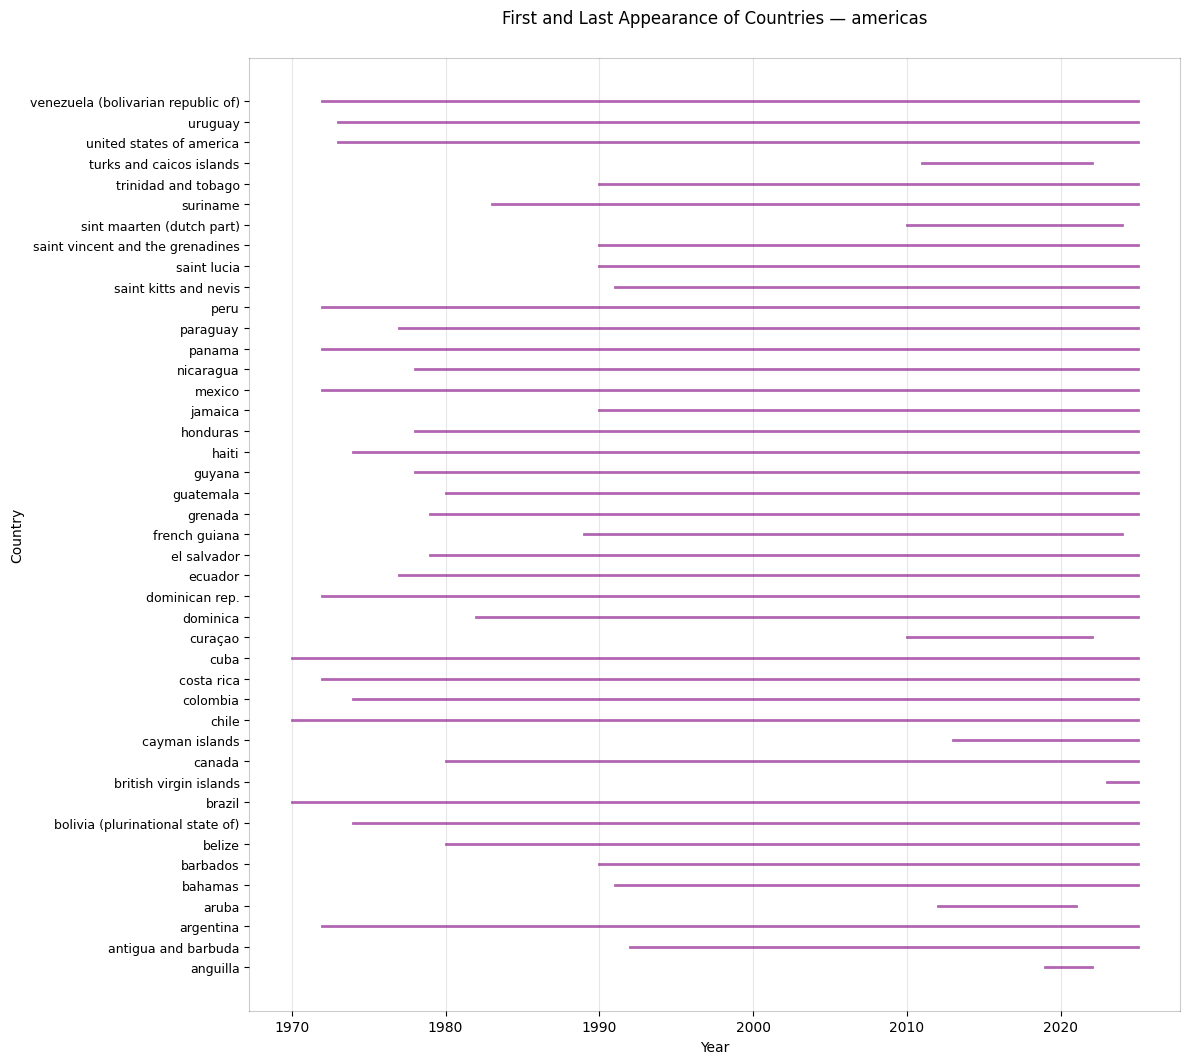

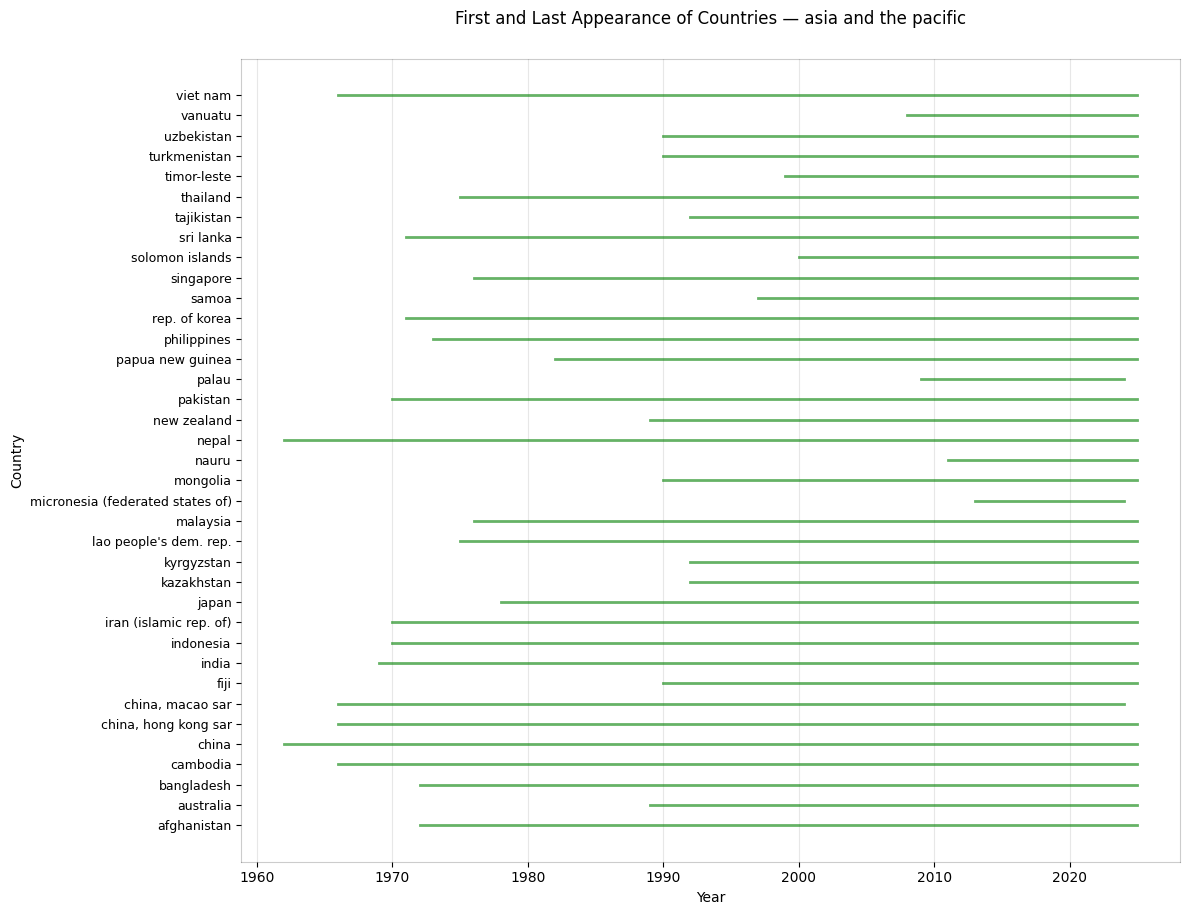

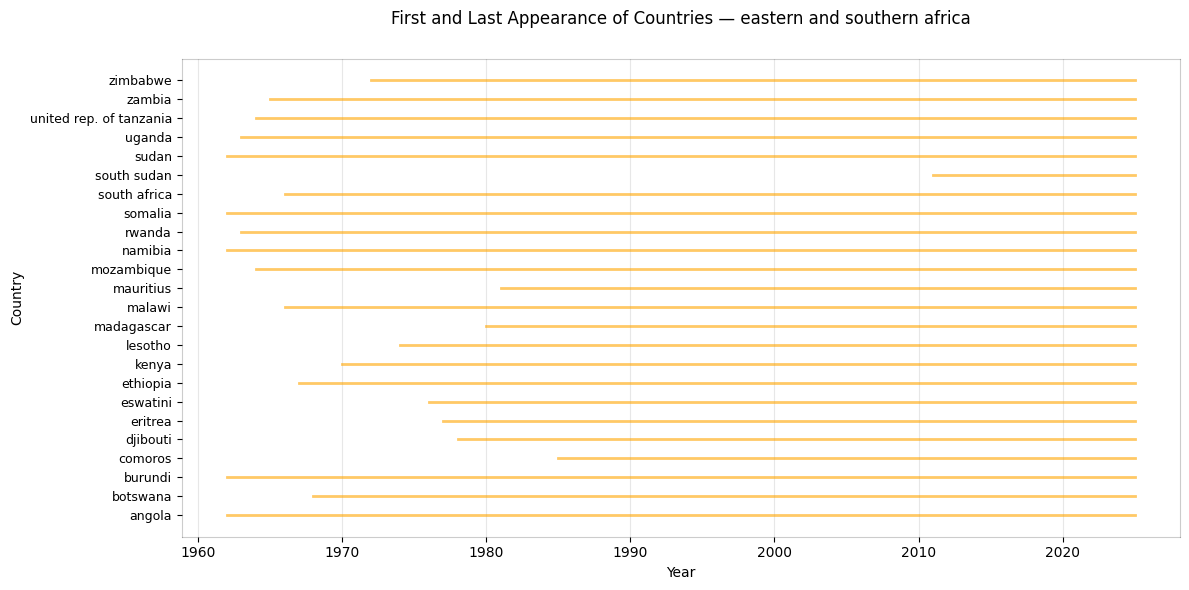

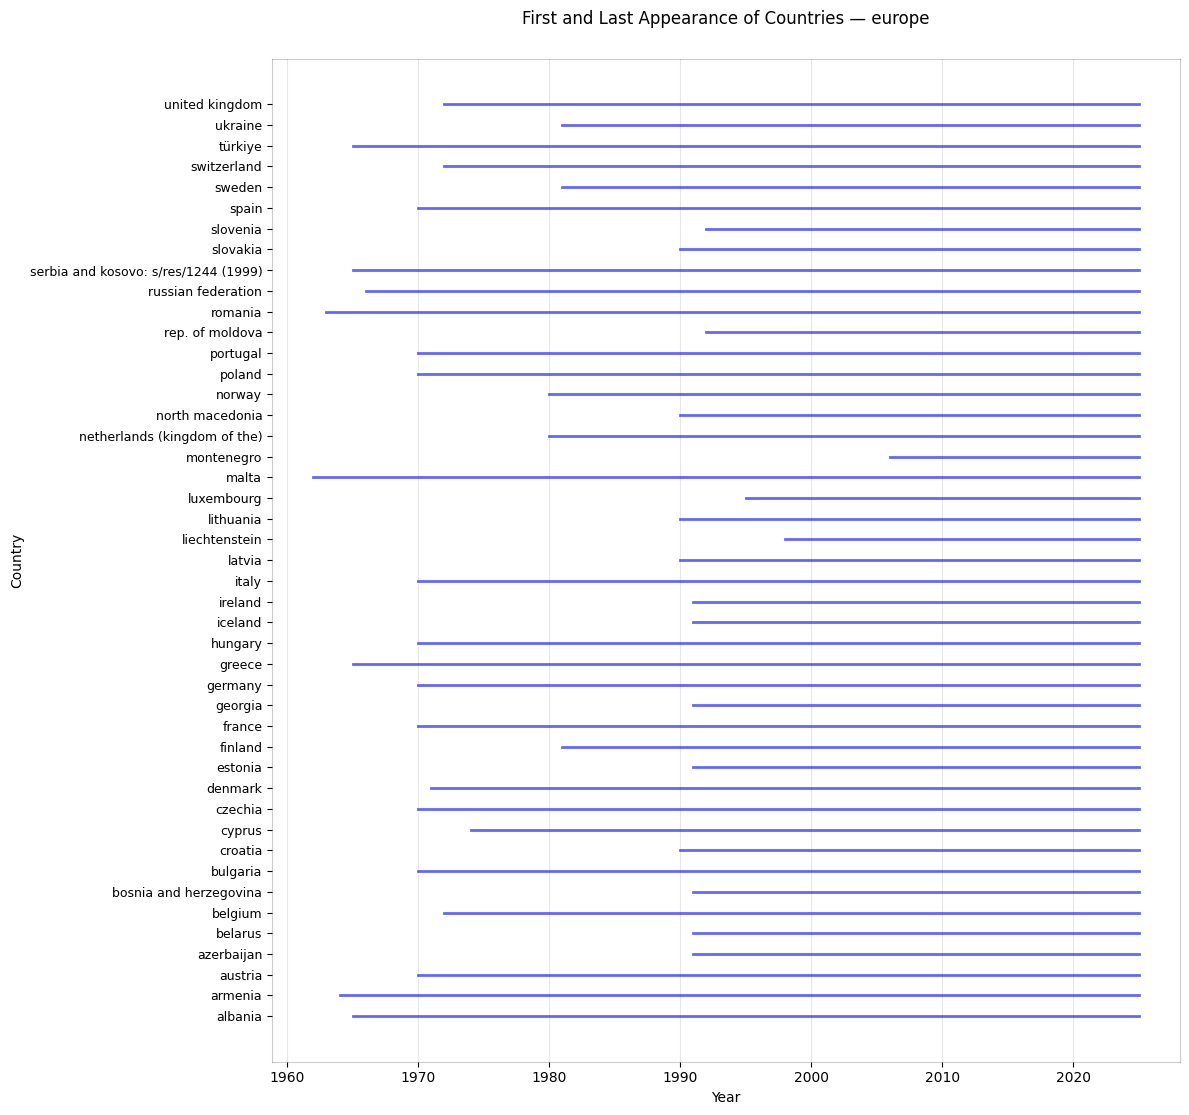

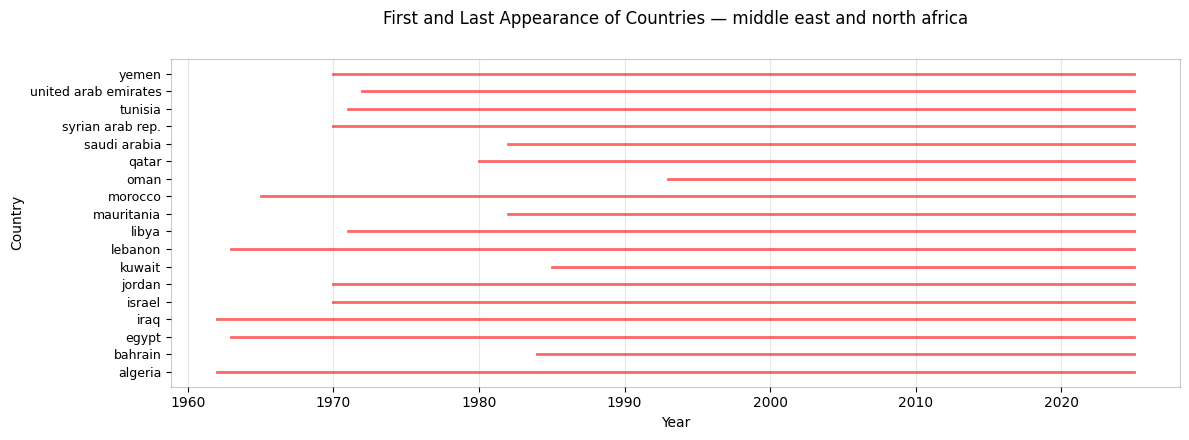

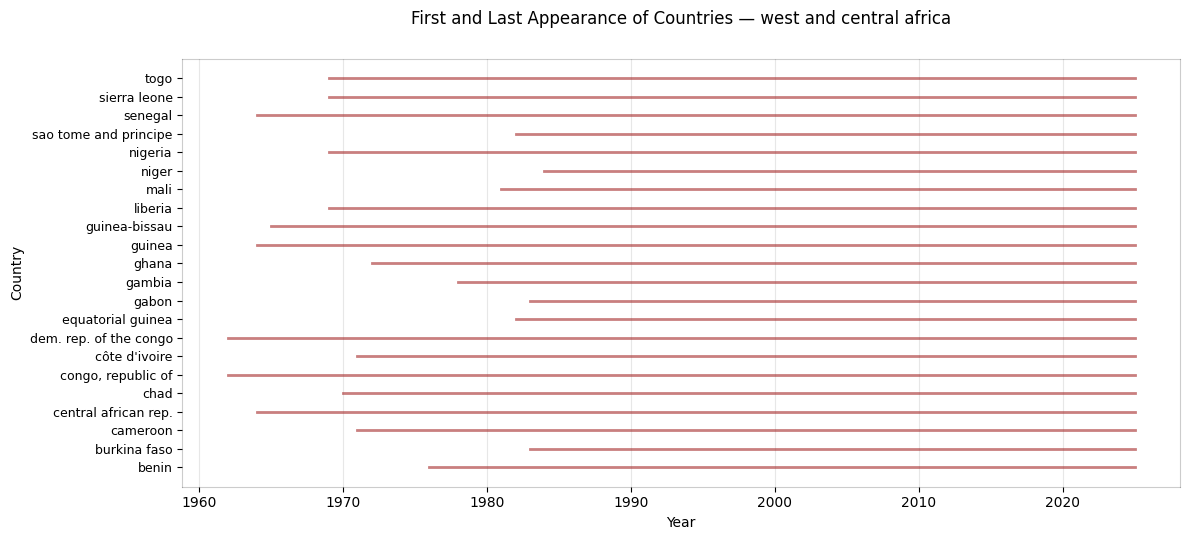

In [69]:
# split into different dataframes by region
country_years_by_region = {
    region: df.reset_index(drop=True)
    for region, df in country_years.groupby('region')
}

region_colors = {
    'europe': 'blue',
    'middle east and north africa': 'red',
    'asia and the pacific': 'green',
    'eastern and southern africa': 'orange',
    'americas': 'purple',
    'west and central africa': 'brown'
}

#---------------------------------
#        LOOP OVER REGIONS
#---------------------------------
for region, df_region in country_years.groupby('region'):

    df_region = df_region.sort_values(by='country').reset_index(drop=True)

    n = len(df_region)
    plt.figure(figsize=(12, n * 0.25))

    for i, row in df_region.iterrows():
        plt.plot(
            [row['start'], row['end']],
            [i, i],
            region_colors.get(region, 'grey'),
            alpha=0.6,
            linewidth=2
        )

    plt.yticks(range(len(df_region)), df_region['country'], fontsize=9)
    plt.xlabel('Year')
    plt.ylabel('Country')
    plt.title(f'First and Last Appearance of Countries — {region}', pad=25)

    # frame opacity
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_alpha(0.2)

    plt.margins(y=0.05)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()

    # save plots
    plt.savefig(f'/Users/tish/Documents/Flexible Masters/02806 - Social data and visualization/CODE_Social_data_Visialization/TishDuc.github.io/Displacements_Final_Project/Graphs and visualizations/first_last_country_apearance_{region}.png', dpi=300)

    plt.show()

year
1962      10
1963       8
1964      14
1965      19
1966      25
        ... 
2021    3289
2022    4754
2023    4547
2024    4238
2025    3121
Name: count, Length: 64, dtype: int64


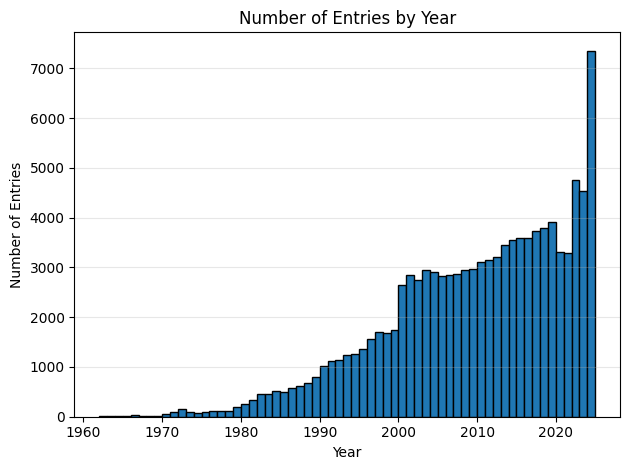

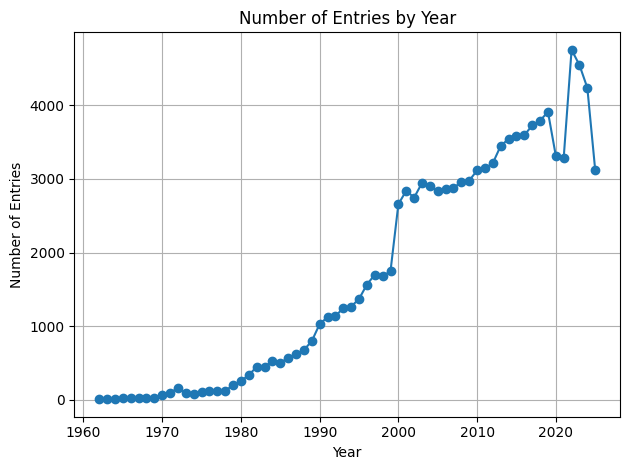

In [65]:
#----------------------------------------------------------
#                       data count 
#----------------------------------------------------------

# count number of entries per year
num_entries_per_year = raw_data['year'].value_counts().sort_index()
print(num_entries_per_year)

# plot as a histogram
plt.hist(raw_data['year'], bins=np.arange(raw_data['year'].min(), raw_data['year'].max() + 1, 1), edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Number of Entries')
plt.title('Number of Entries by Year')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# plot as a line plot
plt.plot(num_entries_per_year.index, num_entries_per_year.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Entries')
plt.title('Number of Entries by Year')
plt.grid()
plt.tight_layout()
plt.show()

In [66]:
# find first time serbia ismentionned
serbia_first_year = raw_data[raw_data['origin'] == 'srb']['year'].min()
print("Serbia first mentioned in:", serbia_first_year)
# last time serbia is mentioned
serbia_last_year = raw_data[raw_data['origin'] == 'srb']['year'].max()
print("Serbia last mentioned in:", serbia_last_year)

# find time when slovenia is mentioned
slovenia_first_year = raw_data[raw_data['originname'] == 'slovenia']['year'].min()
print("Slovenia first mentioned in:", slovenia_first_year)

# first time "Russian Federation" is mentioned
russia_first_year = raw_data[raw_data['originname'] == 'russian federation']['year'].min()
print("Russian Federation first mentioned in:", russia_first_year)

# last time "Russian Federation" is mentioned
russia_last_year = raw_data[raw_data['originname'] == 'russian federation']['year'].max()
print("Russian Federation last mentioned in:", russia_last_year)    

# last time "yugoslavia" is mentioned
yugoslavia_last_year = raw_data[raw_data['origin'] == 'yu']['year'].max()
print("Yugoslavia last mentioned in:", yugoslavia_last_year)    

# montenegro
yugoslavia_first_year = raw_data[raw_data['origin'] == 'mne']['year'].min()
print("firet mention of montenegro", yugoslavia_first_year)

# first time "timor" is mentioned
timor_first_year = raw_data[raw_data['originname'] == 'timor-leste']['year'].min()
print("Timor-Leste first mentioned in:", timor_first_year)


Serbia first mentioned in: 1970
Serbia last mentioned in: 2025
Slovenia first mentioned in: 1992
Russian Federation first mentioned in: 1966
Russian Federation last mentioned in: 2025
Yugoslavia last mentioned in: nan
firet mention of montenegro 2006
Timor-Leste first mentioned in: 1999


In [67]:
# date the first time a country of origin appears in the dataset
first_country_appearance = raw_data.groupby('originname')['year'].min()
print(first_country_appearance)


originname
afghanistan       1972
albania           1965
algeria           1962
andorra           1989
angola            1962
                  ... 
viet nam          1966
western sahara    1987
yemen             1970
zambia            1968
zimbabwe          1972
Name: year, Length: 213, dtype: int64


In [68]:


# --------------------------------------
# filter data
# --------------------------------------

flow_data = raw_data.copy()

flow_data = flow_data[flow_data['year'] == 2024]
flow_data = flow_data[flow_data['population types'] == 'ref']

flow_data = (
    flow_data
    .groupby(['originiso', 'asylumiso'], as_index=False)['count']
    .sum()
    .sort_values('count', ascending=False)
    .head(100)
)

# --------------------------------------
# get country centroids
# --------------------------------------

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world = world[['ADM0_A3', 'ADMIN', 'geometry']].copy()
world = world.rename(columns={'ADM0_A3': 'iso_a3', 'ADMIN': 'name'})
world = world[world['iso_a3'] != '-99'].copy()

world_proj = world.to_crs('+proj=robin')
world['centroid'] = world_proj.geometry.centroid.to_crs(world.crs)
world['lon'] = world['centroid'].x
world['lat'] = world['centroid'].y

centroids = world[['iso_a3', 'lat', 'lon']].copy()

origin_coords = centroids.rename(columns={
    'iso_a3': 'originiso',
    'lat': 'origin_lat',
    'lon': 'origin_lon'
})

asylum_coords = centroids.rename(columns={
    'iso_a3': 'asylumiso',
    'lat': 'asylum_lat',
    'lon': 'asylum_lon'
})

flow_data = flow_data.merge(origin_coords, on='originiso', how='left')
flow_data = flow_data.merge(asylum_coords, on='asylumiso', how='left')
flow_data = flow_data.dropna()

# --------------------------------------
# build plotly flow map
# --------------------------------------

fig = go.Figure()

max_count = flow_data['count'].max()

for _, row in flow_data.iterrows():
    fig.add_trace(go.Scattergeo(
        lon=[row['origin_lon'], row['asylum_lon']],
        lat=[row['origin_lat'], row['asylum_lat']],
        mode='lines',
        line=dict(width=max(1, row['count'] / max_count * 8)),
        opacity=0.35,
        hoverinfo='text',
        text=f"{row['originiso']} → {row['asylumiso']}<br>Count: {row['count']}"
    ))

fig.update_layout(
    title='Refugee flows by country',
    showlegend=False,
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor='rgb(230, 230, 230)',
        showcountries=True
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()